# Changes in complex-rule Lift

In [1]:
import os
import sys
from dataclasses import replace
sys.path[:0] = [os.path.abspath("scripts"), os.path.abspath(".."), os.path.abspath("../differential_rules/scripts")]
import complex_investigation as ci
import complex_investigation_vis as vis
from IPython.display import display

In [2]:
CONFIG = ci.Config(support=0.01, expected_support=0.01, confidence=0.5,
                   min_cells=20, min_fovs=5, min_patients=3,
                   min_group_fovs=10, permutations=4999, top_n=8,
                   max_items=3)

This screen asks whether a passing rule becomes stronger, even when its prevalence barely changes. Selection requires at least five rule-bearing eligible FOVs and three patients in both compared stages. Visible-effect cutoffs are 0.30 median Lift units for attraction and 0.15 for avoidance. Each organ/state has two display slots. No rule names are preselected.

In [3]:
cells, metadata, rules = ci.load(CONFIG)
occurrence = ci.analyse(rules, cells, metadata, CONFIG)
analysis, SPECS = ci.strength_screen(occurrence, metadata)
ci.save_tables(analysis, SPECS, 'strength_clin')
display(SPECS)

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv + results_CN_complex.csv
{'max_items': 3, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
145,687 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None

,organ,rule,kind,gap,contrast,patient_fdr,stream,test_metric
0,Duodenum,Muscle + SMV -> Endothelial,attracts,0.825076,Mild–Severe,0.651440,conditional Lift,Lift
1,Duodenum,Muscle -> CD4T + CD8T,avoids,0.290837,Mild–Severe,0.734696,conditional Lift,Lift
2,Colon,CD4T + Macrophage -> Goblet,avoids,0.281608,Control–Severe,0.734696,conditional Lift,Lift
3,Duodenum,Muscle + SMV -> CD4T,avoids,0.281089,Mild–Severe,0.734696,conditional Lift,Lift
4,Colon,CD4T + Macrophage -> Muscle,avoids,0.261420,Control–Severe,0.651440,conditional Lift,Lift


The header tests conditional mean Lift, not occurrence; plots show raw FOV Lift and medians. FOV, biopsy and patient permutation tests reuse the differential methods (4,999 permutations; seed 0), with one BH family per unit over organs, states and contrasts. Patient values are means of biopsy means; cross-stage patients are omitted from unpaired tests. Missing or filtered rules do not get Lift = 1. This is a threshold-conditioned descriptive comparison, not evidence that every neighborhood changed.

In [4]:
def show_selected(index):
    vis.show_selected(index, SPECS, analysis, rules, cells, metadata,
                      'strength_clin', parents=True)

**[0] Duodenum · Muscle + SMV -> Endothelial**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,11,70,170,10,35
1,All,avoids,1,70,170,1,35
2,Control,attracts,0,12,31,0,7
3,Control,avoids,0,12,31,0,7
4,Mild,attracts,6,38,98,5,20
5,Mild,avoids,1,38,98,1,20
6,Severe,attracts,5,20,41,5,8
7,Severe,avoids,0,20,41,0,8


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_4ab71d3d66_parent_vs_complex.pdf


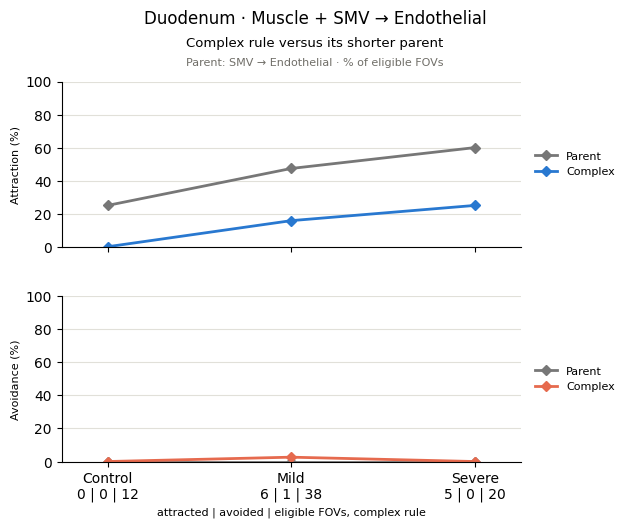

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_4ab71d3d66_summary.pdf


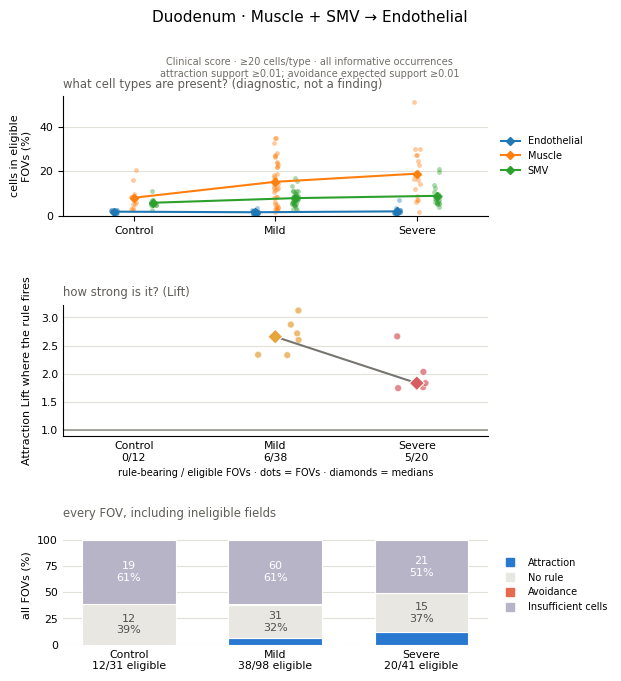

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_4ab71d3d66_parents.pdf


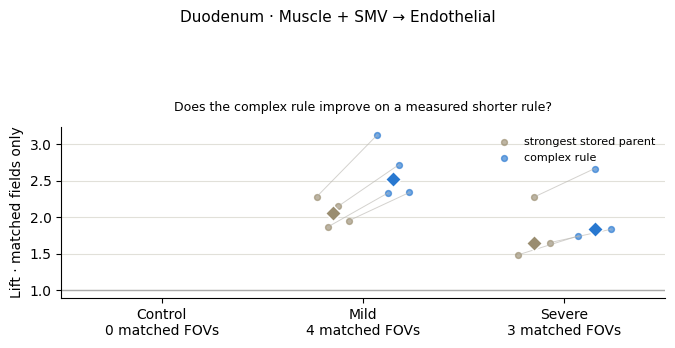

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Severe,3,1.833158,1.653019,3
Mild,4,2.526747,2.051453,4


Read results_CN_pairwise.csv + results_CN_complex.csv
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_4ab71d3d66_fovs_attraction_mild.pdf


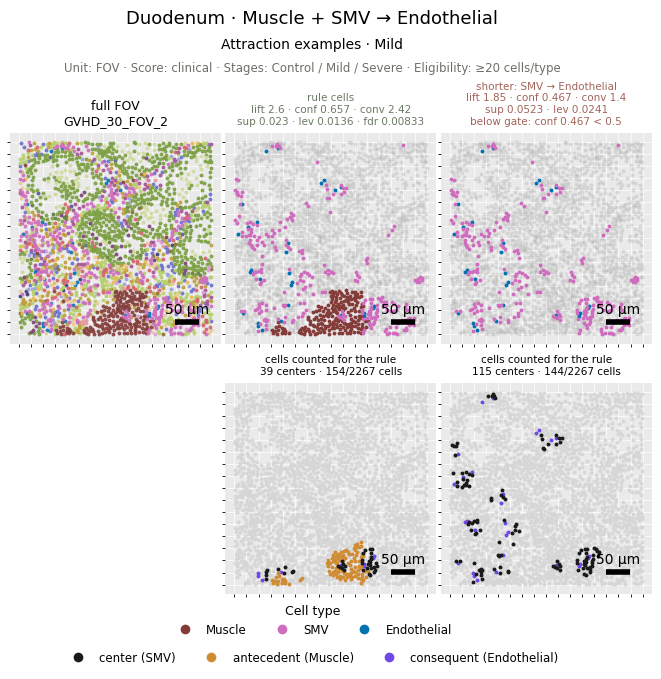

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_4ab71d3d66_fovs_attraction_severe.pdf


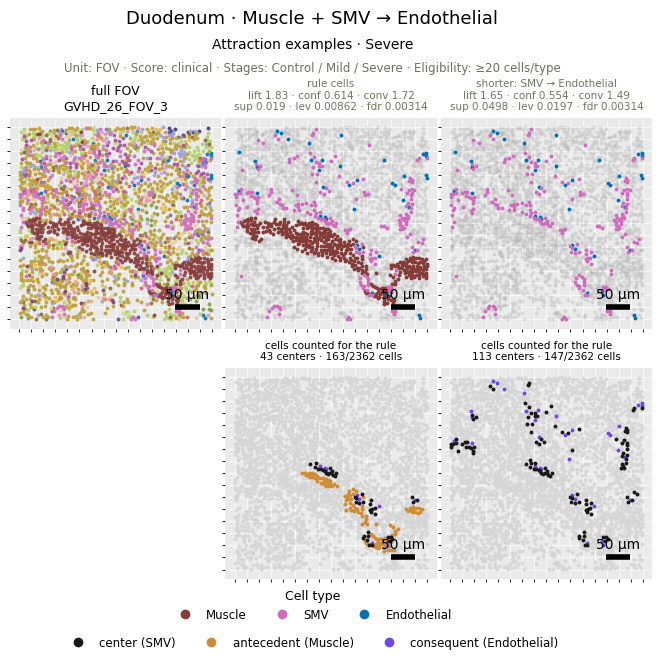

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_4ab71d3d66_fovs_avoidance_mild.pdf


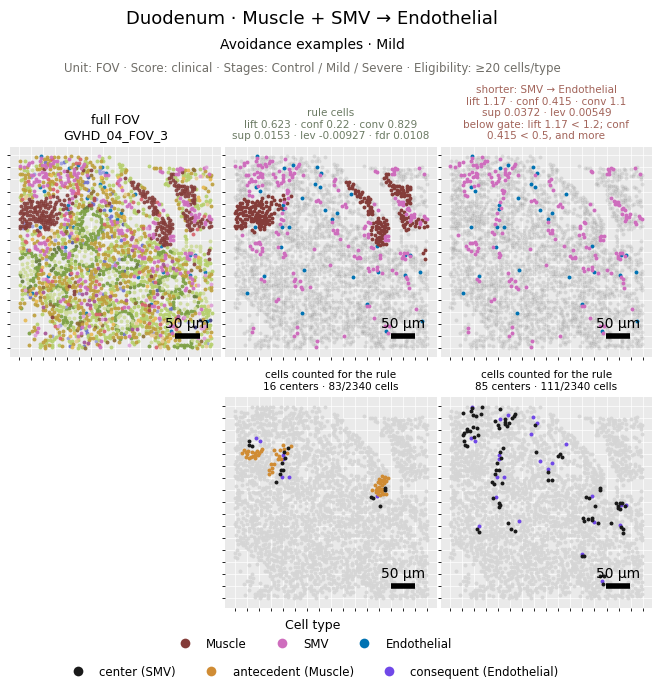

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_4ab71d3d66_fovs_no_rule.pdf


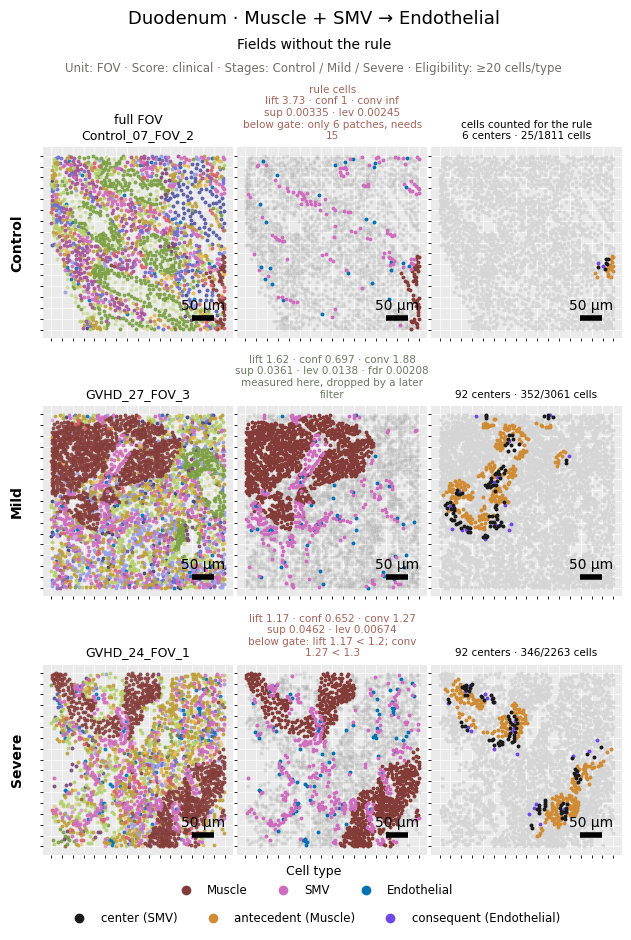

In [5]:
show_selected(0)

**[1] Duodenum · Muscle -> CD4T + CD8T**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,70,170,0,28
1,All,avoids,21,70,170,12,28
2,Control,attracts,0,17,31,0,7
3,Control,avoids,3,17,31,2,7
4,Mild,attracts,0,33,98,0,13
5,Mild,avoids,9,33,98,6,13
6,Severe,attracts,0,20,41,0,8
7,Severe,avoids,9,20,41,4,8


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_adf4ed1c50_parent_vs_complex.pdf


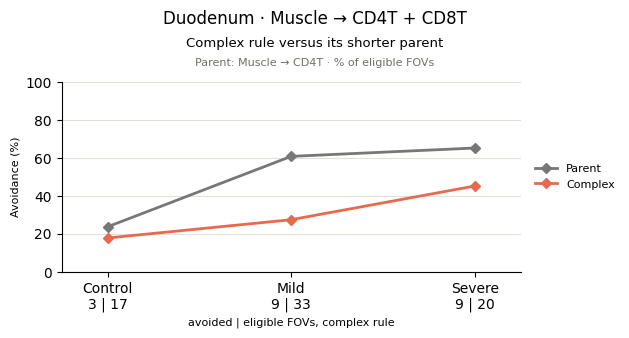

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_adf4ed1c50_summary.pdf


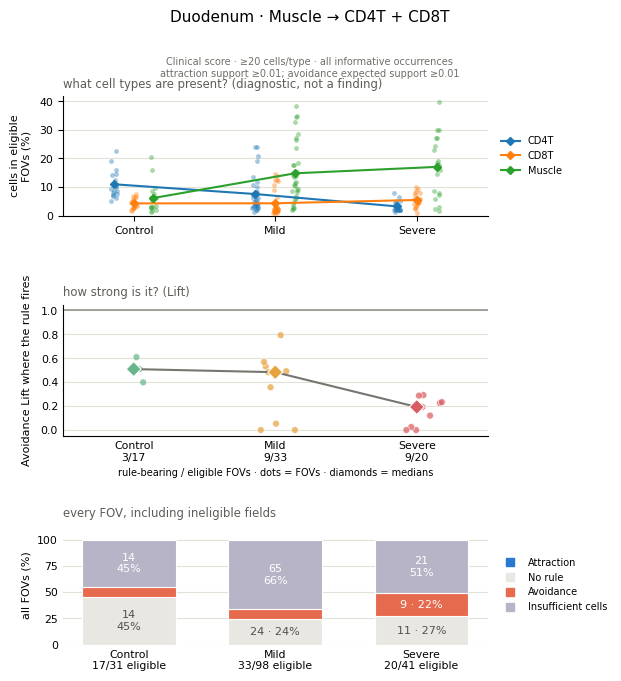

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_adf4ed1c50_parents.pdf


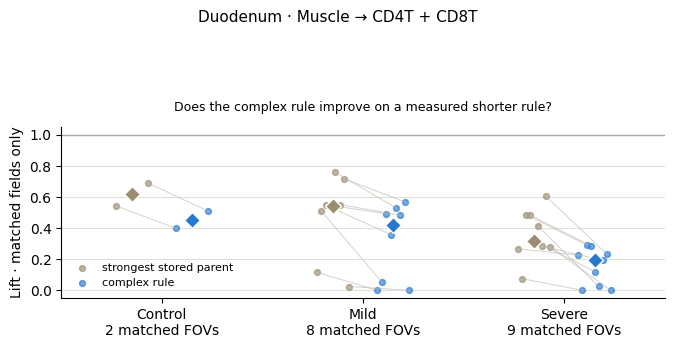

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,2,0.454213,0.617710,2
Mild,8,0.420965,0.542616,8
Severe,9,0.193022,0.320276,9


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_adf4ed1c50_fovs_avoidance_control.pdf


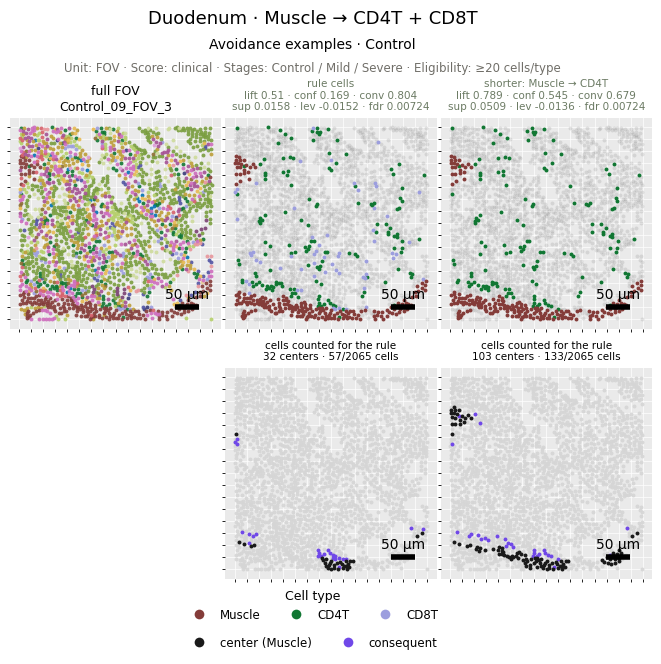

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_adf4ed1c50_fovs_avoidance_mild.pdf


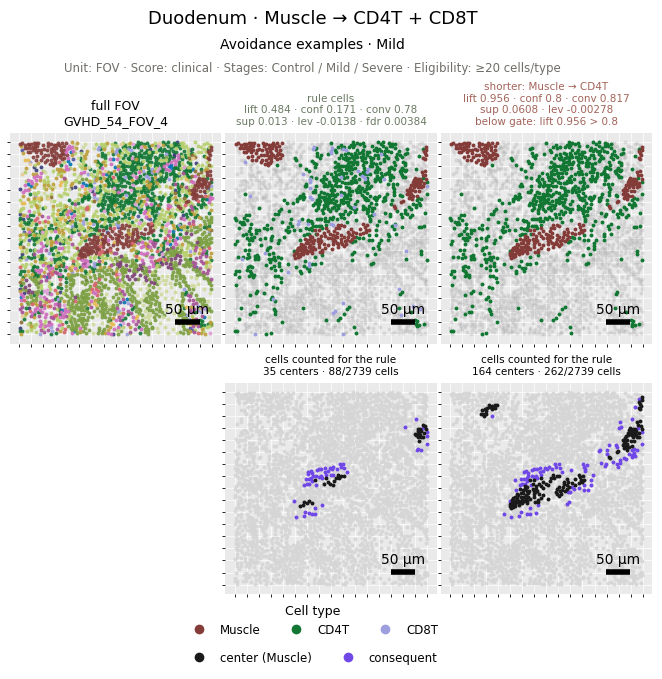

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_adf4ed1c50_fovs_avoidance_severe.pdf


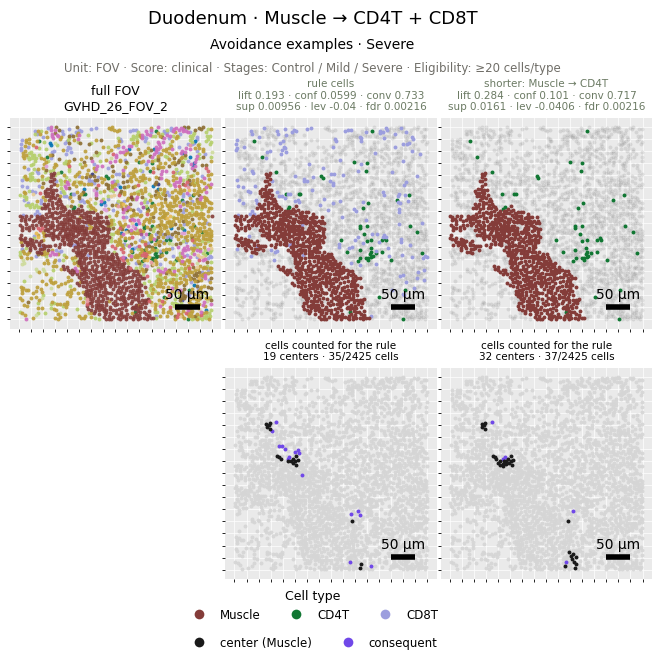

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_adf4ed1c50_fovs_no_rule.pdf


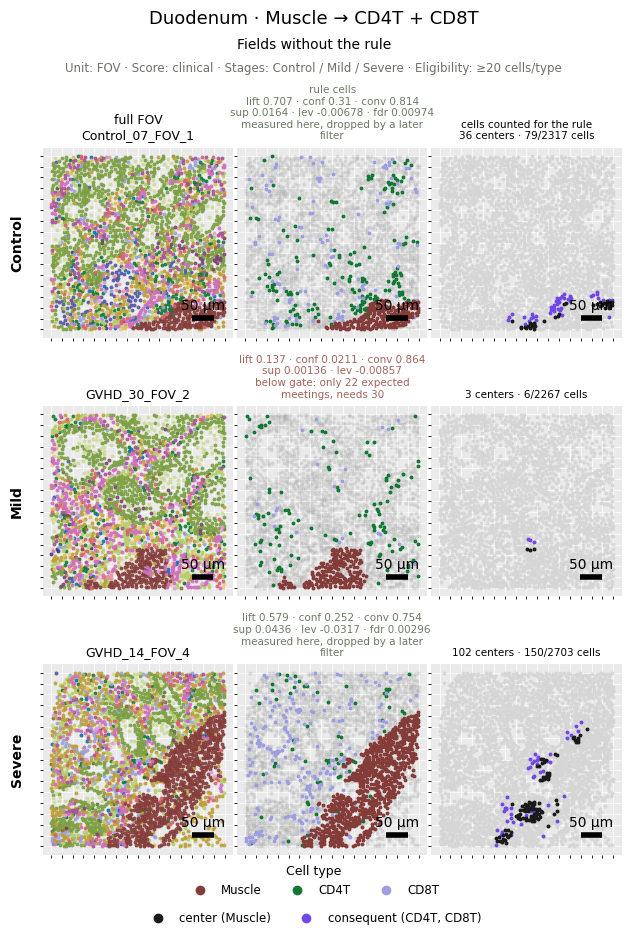

In [6]:
show_selected(1)

**[2] Colon · CD4T + Macrophage -> Goblet**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,71,97,0,18
1,All,avoids,31,71,97,15,18
2,Control,attracts,0,25,25,0,4
3,Control,avoids,13,25,25,4,4
4,Mild,attracts,0,9,18,0,3
5,Mild,avoids,1,9,18,1,3
6,Severe,attracts,0,37,54,0,11
7,Severe,avoids,17,37,54,10,11


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_37a8193a41_parent_vs_complex.pdf


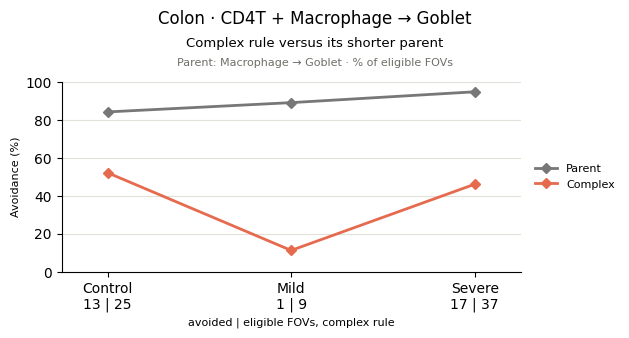

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_37a8193a41_summary.pdf


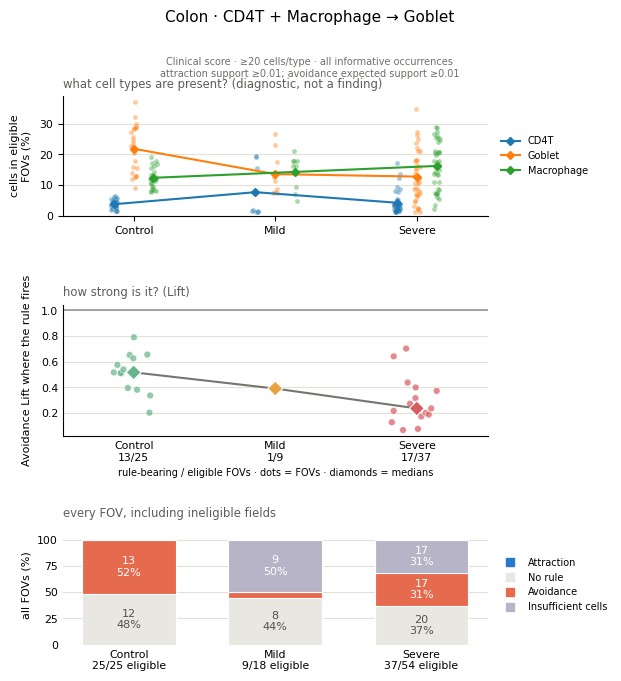

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_37a8193a41_parents.pdf


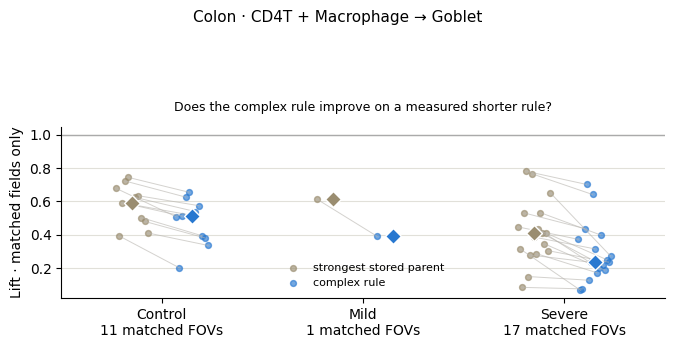

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,11,0.511544,0.593139,11
Severe,17,0.235059,0.408159,17
Mild,1,0.390120,0.614344,1


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_37a8193a41_fovs_avoidance_control.pdf


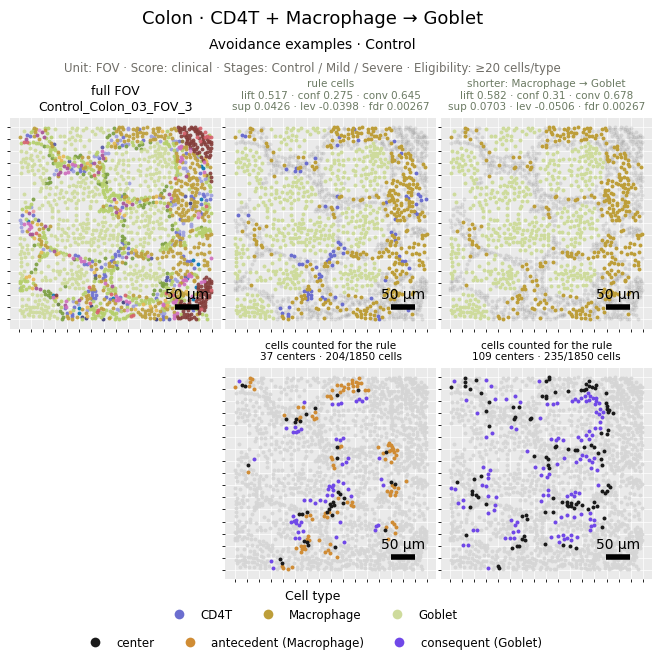

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_37a8193a41_fovs_avoidance_mild.pdf


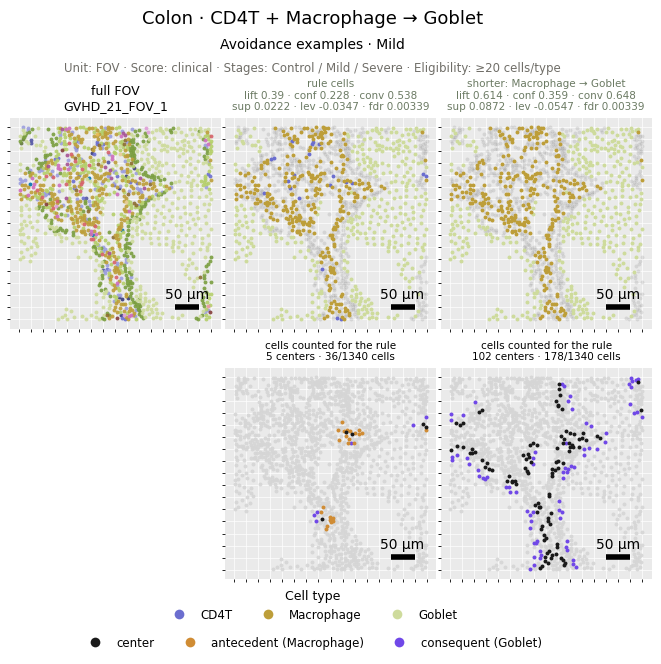

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_37a8193a41_fovs_avoidance_severe.pdf


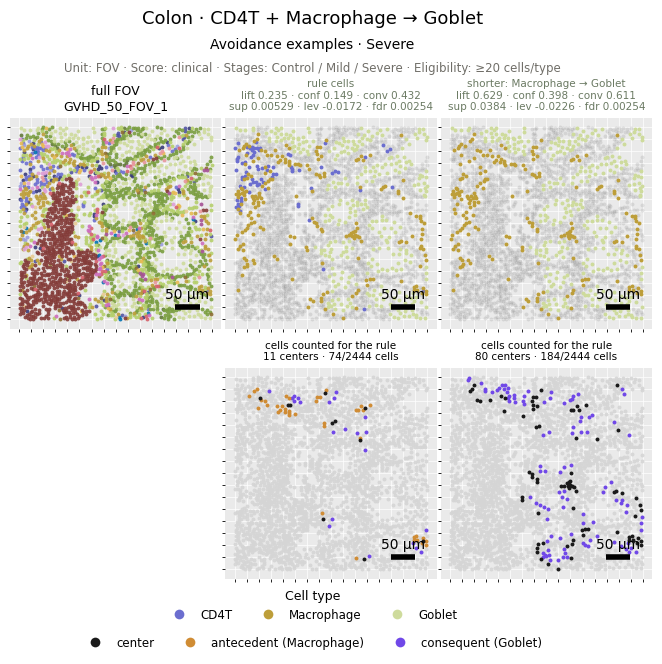

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_37a8193a41_fovs_no_rule.pdf


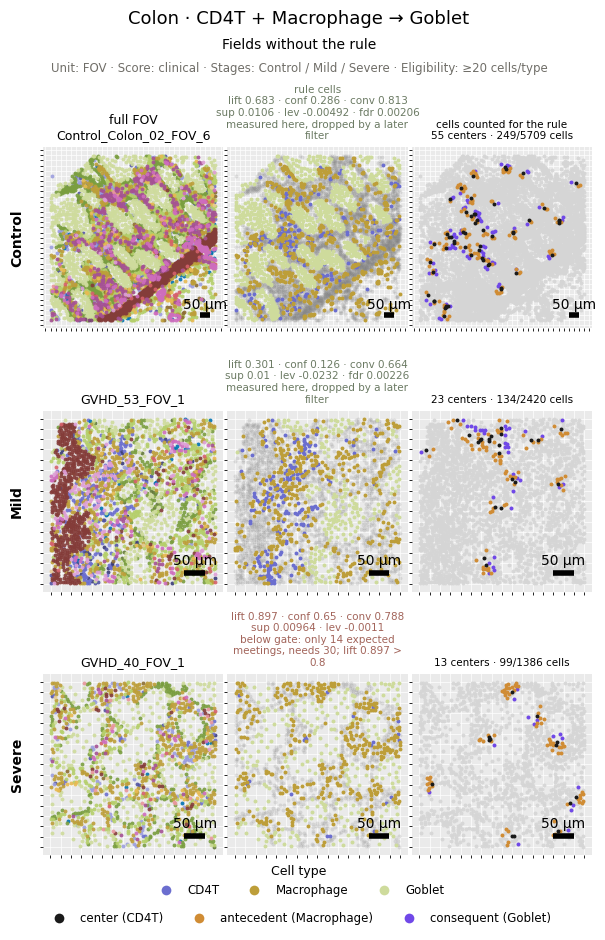

In [7]:
show_selected(2)

**[3] Duodenum · Muscle + SMV -> CD4T**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,3,98,170,3,39
1,All,avoids,13,98,170,11,39
2,Control,attracts,1,17,31,1,8
3,Control,avoids,3,17,31,2,8
4,Mild,attracts,2,56,98,2,22
5,Mild,avoids,5,56,98,5,22
6,Severe,attracts,0,25,41,0,9
7,Severe,avoids,5,25,41,4,9


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_parent_vs_complex.pdf


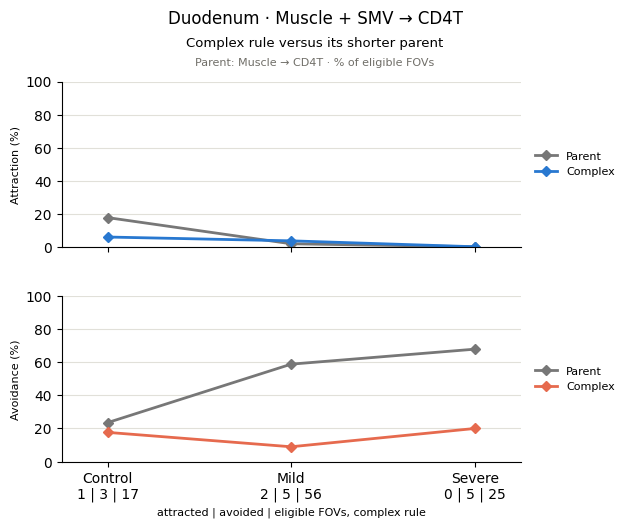

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_summary.pdf


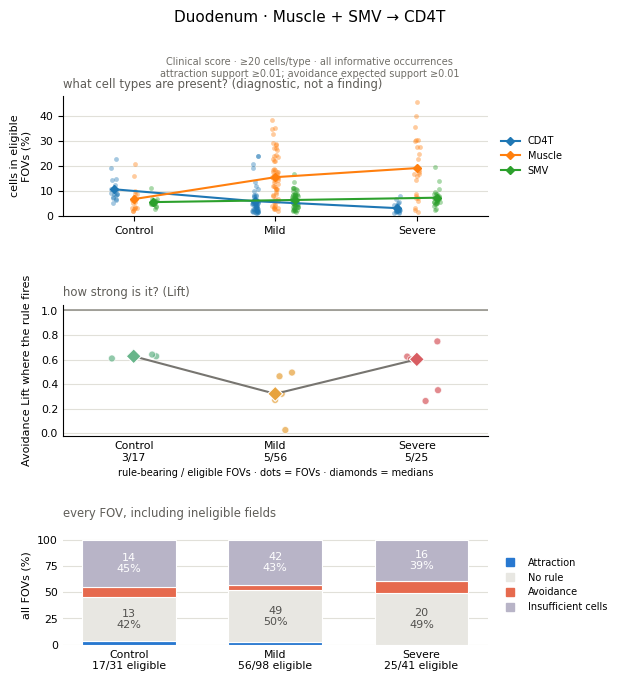

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_parents.pdf


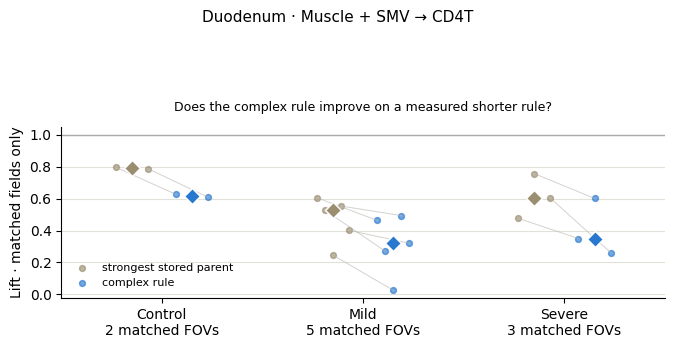

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,2,0.617659,0.793172,2
Mild,5,0.320541,0.527871,5
Severe,3,0.350194,0.603977,3


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_fovs_attraction_control.pdf


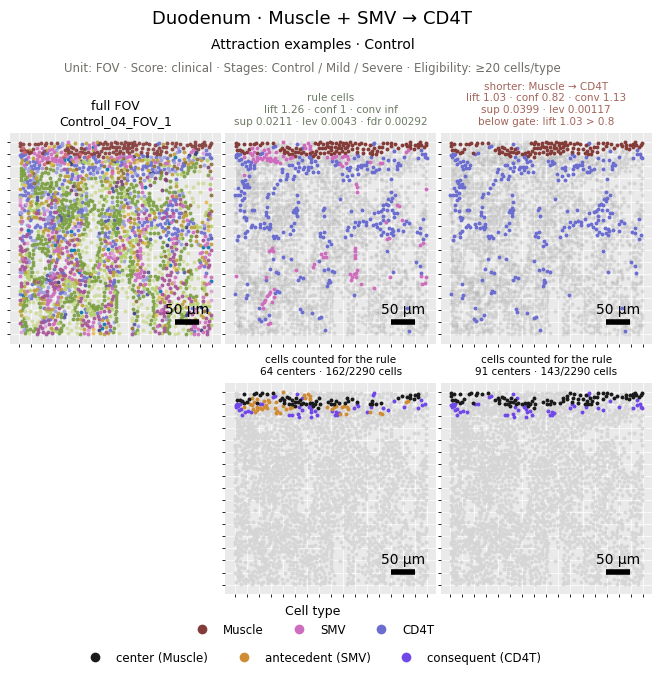

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_fovs_attraction_mild.pdf


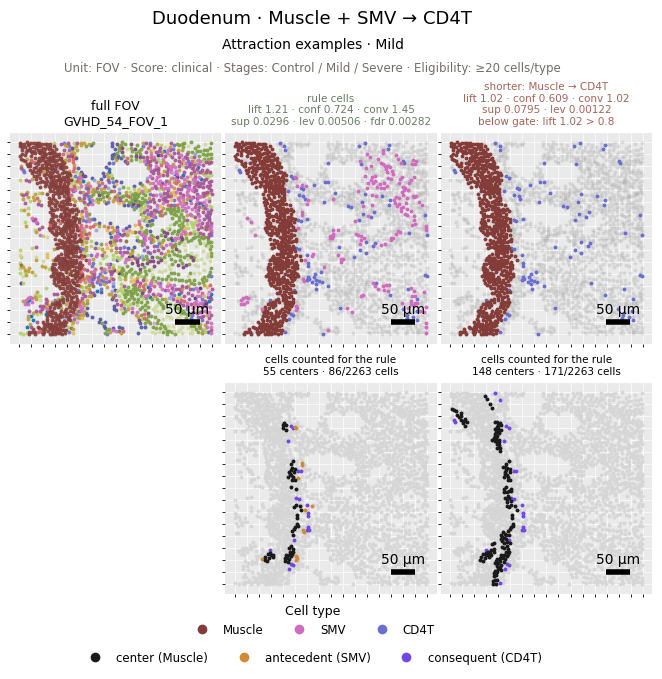

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_fovs_avoidance_control.pdf


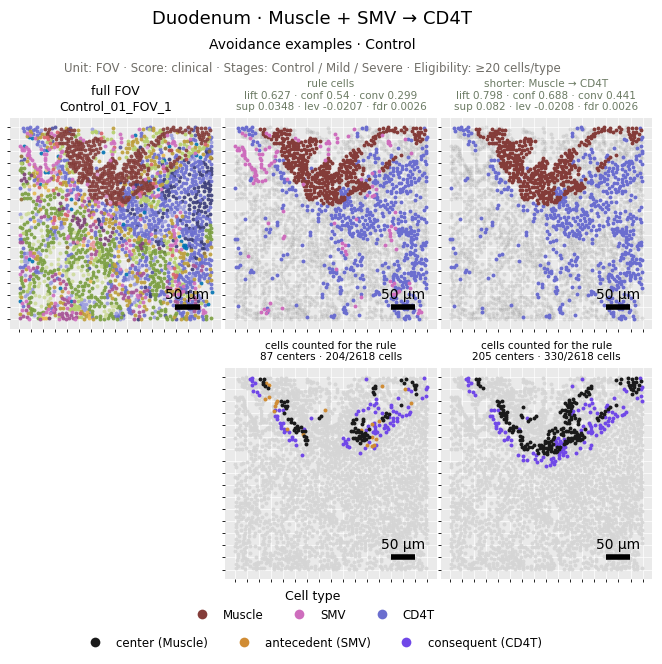

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_fovs_avoidance_mild.pdf


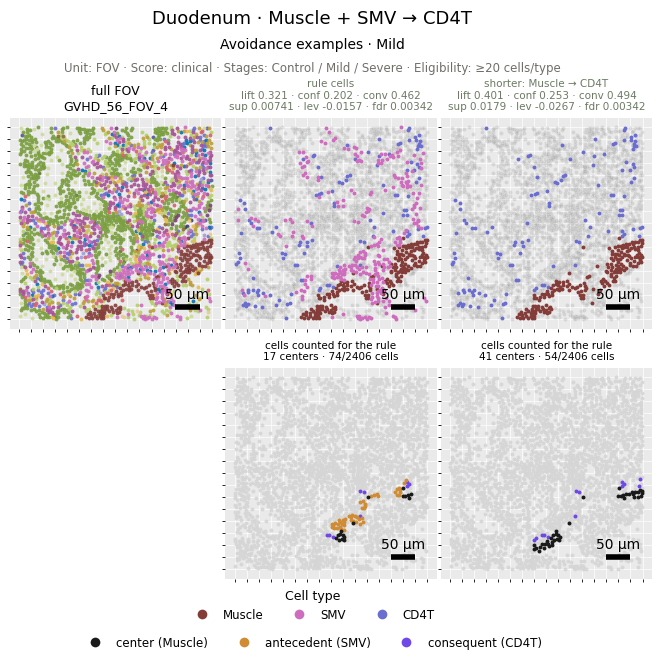

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_fovs_avoidance_severe.pdf


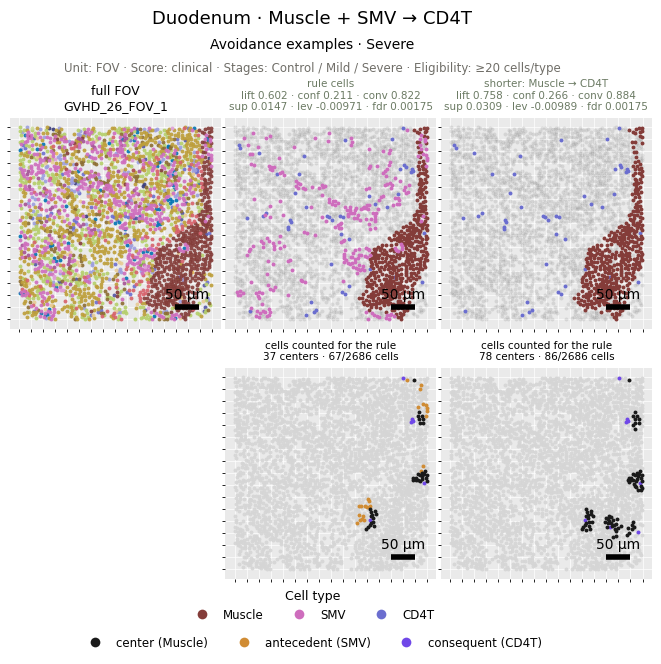

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Duodenum_08d587b524_fovs_no_rule.pdf


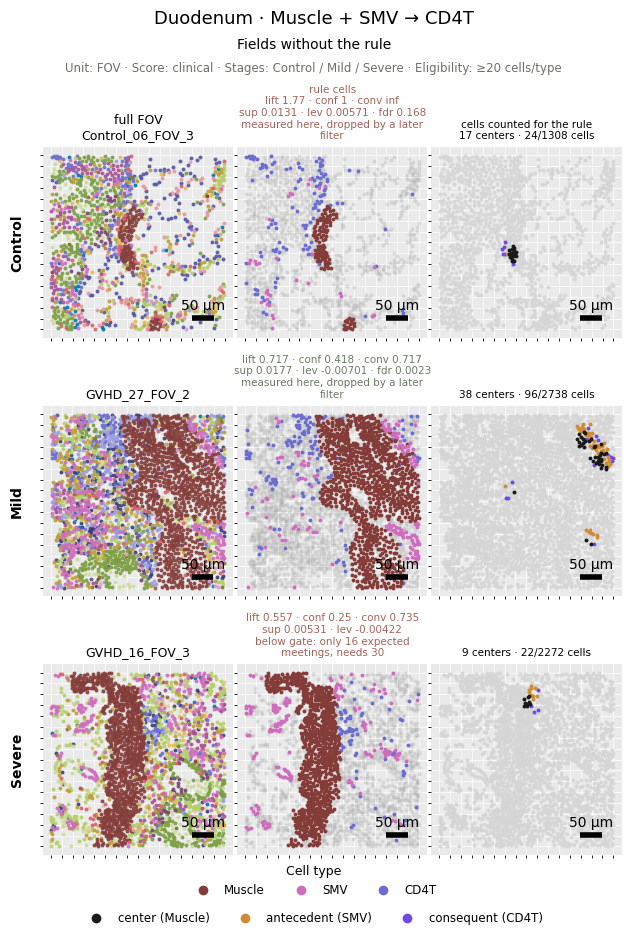

In [8]:
show_selected(3)

**[4] Colon · CD4T + Macrophage -> Muscle**

,stage,kind,hits,eligible,total,hit_patients,patients
0,All,attracts,0,44,97,0,15
1,All,avoids,16,44,97,9,15
2,Control,attracts,0,20,25,0,4
3,Control,avoids,7,20,25,3,4
4,Mild,attracts,0,3,18,0,2
5,Mild,avoids,0,3,18,0,2
6,Severe,attracts,0,21,54,0,9
7,Severe,avoids,9,21,54,6,9


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_35bf6e646f_parent_vs_complex.pdf


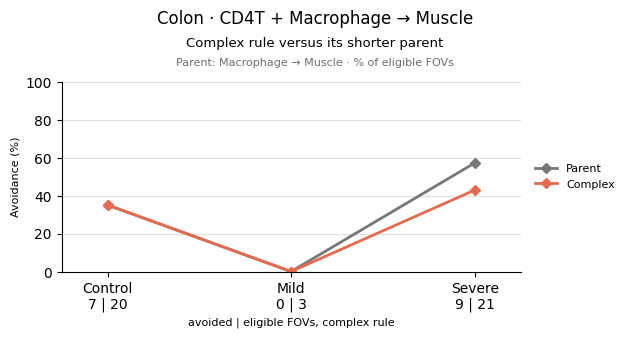

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_35bf6e646f_summary.pdf


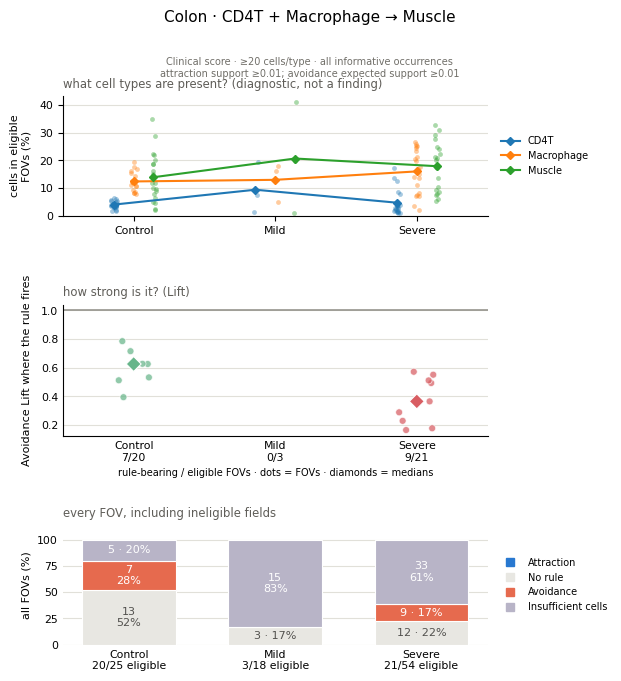

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_35bf6e646f_parents.pdf


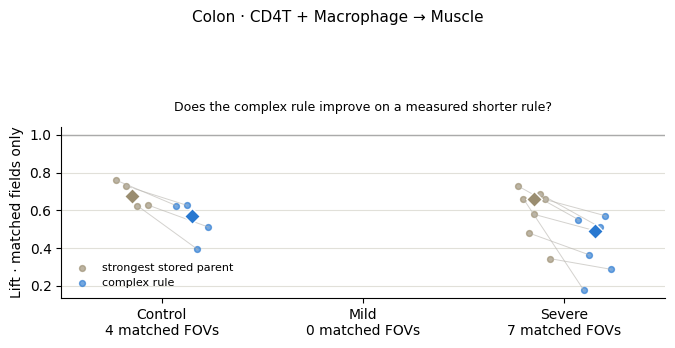

,matched_fovs,median_complex_lift,median_parent_lift,significant_parents
stage,,,,
Control,4,0.568819,0.678675,4
Severe,7,0.492717,0.658029,7


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_35bf6e646f_fovs_avoidance_control.pdf


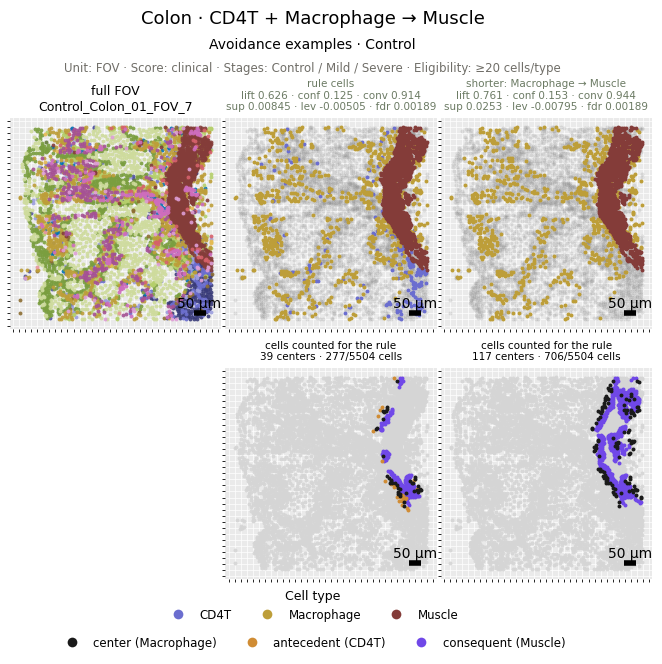

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_35bf6e646f_fovs_avoidance_severe.pdf


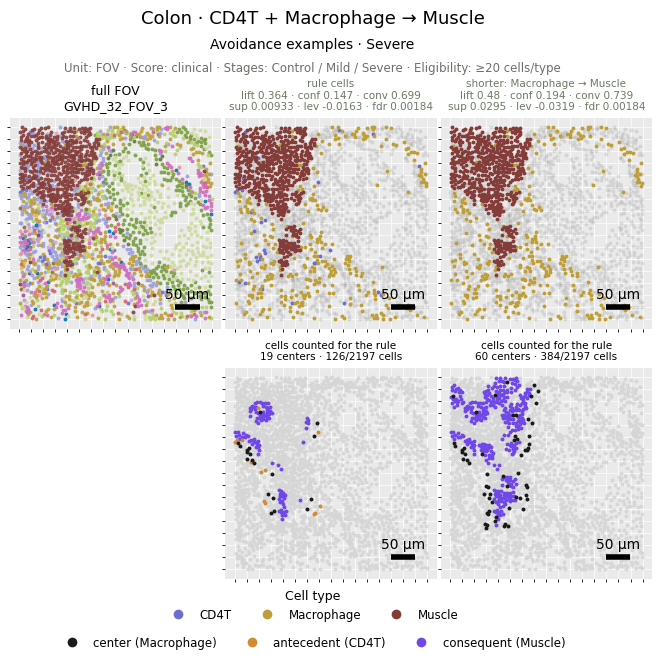

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\strength_clin_Colon_35bf6e646f_fovs_no_rule.pdf


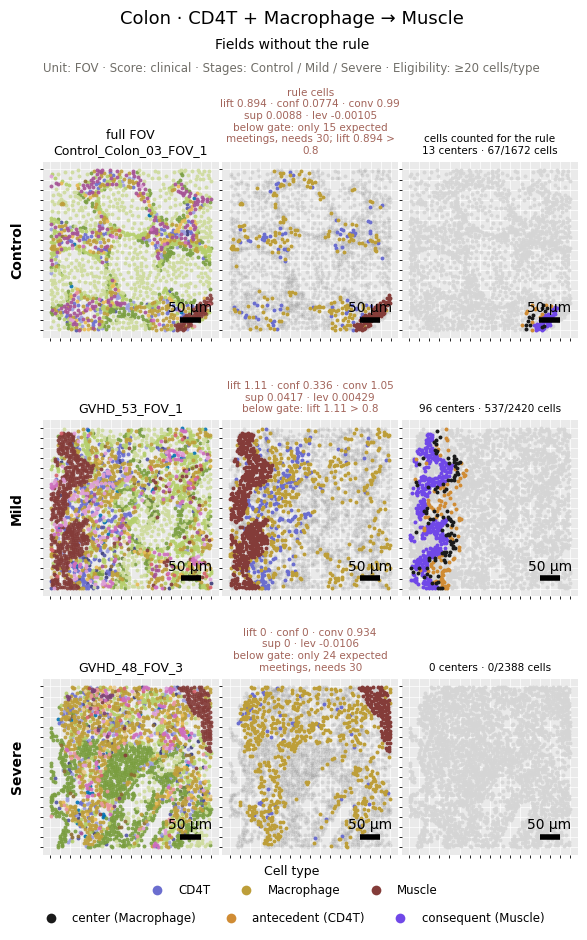

In [9]:
show_selected(4)

In [10]:
show_selected(5)

No result at index 5; 5 selected results.


In [11]:
show_selected(6)

No result at index 6; 5 selected results.


In [12]:
show_selected(7)

No result at index 7; 5 selected results.
